In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

In [10]:
x = np.array([0.218, 0.559, 0.900, 1.242, 1.583, 1.924, 2.266, 2.607, 2.948])
y = np.array([0.511, 0.980, 1.561, 1.872, 2.439, 2.900, 3.495, 3.953, 4.561])

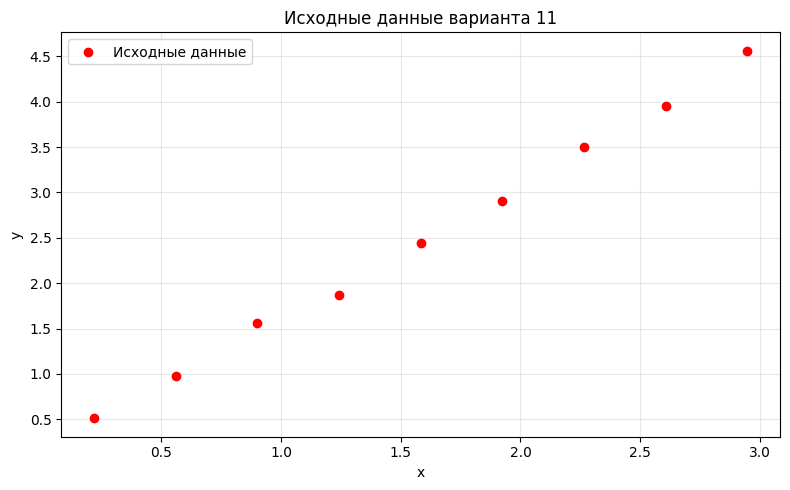

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='red', label='Исходные данные', zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Исходные данные варианта 11')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def residual(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

In [13]:
# закон 1: y = ax^2 + bx + c
def model1(x, a, b, c):
    return a * x**2 + b * x + c

n = len(x)
Sx = np.sum(x)
Sx2 = np.sum(x**2)
Sx3 = np.sum(x**3)
Sx4 = np.sum(x**4)
Sy = np.sum(y)
Sxy = np.sum(x * y)
Sx2y = np.sum(x**2 * y)

A1 = np.array([[Sx4, Sx3, Sx2],
               [Sx3, Sx2, Sx],
               [Sx2, Sx,  n]])
B1 = np.array([Sx2y, Sxy, Sy])

a1, b1, c1 = solve(A1, B1)
print(f"Закон 1: y = {a1:.6f}x² + {b1:.6f}x + {c1:.6f}")

y_pred1 = model1(x, a1, b1, c1)
delta1 = residual(y, y_pred1)
print(f"Невязка = {delta1:.6f}")

Закон 1: y = 0.057594x² + 1.283369x + 0.254043
Невязка = 0.048083


In [14]:
# закон 6: y = ax + b*e^(-x) + c
phi1 = x
phi2 = np.exp(-x)
phi3 = np.ones(n)

G = np.array([
    [np.sum(phi1*phi1), np.sum(phi1*phi2), np.sum(phi1*phi3)],
    [np.sum(phi2*phi1), np.sum(phi2*phi2), np.sum(phi2*phi3)],
    [np.sum(phi3*phi1), np.sum(phi3*phi2), np.sum(phi3*phi3)]
])
F = np.array([np.sum(y*phi1), np.sum(y*phi2), np.sum(y*phi3)])

a6, b6, c6 = solve(G, F)
print(f"Закон 6: y = {a6:.6f}x + {b6:.6f}e^(-x) + {c6:.6f}")

y_pred6 = a6 * x + b6 * np.exp(-x) + c6
delta6 = residual(y, y_pred6)
print(f"Невязка = {delta6:.6f}")

Закон 6: y = 1.569570x + 0.405167e^(-x) + -0.129379
Невязка = 0.051867


In [15]:
print(f"Закон 1 (полином 2-й степени): невязка = {delta1:.6f}")
print(f"Закон 6 (ax + be^(-x) + c):    невязка = {delta6:.6f}")
print(f"\nНаилучшая аппроксимация: Закон {1 if delta1 < delta6 else 6}")

Закон 1 (полином 2-й степени): невязка = 0.048083
Закон 6 (ax + be^(-x) + c):    невязка = 0.051867

Наилучшая аппроксимация: Закон 1


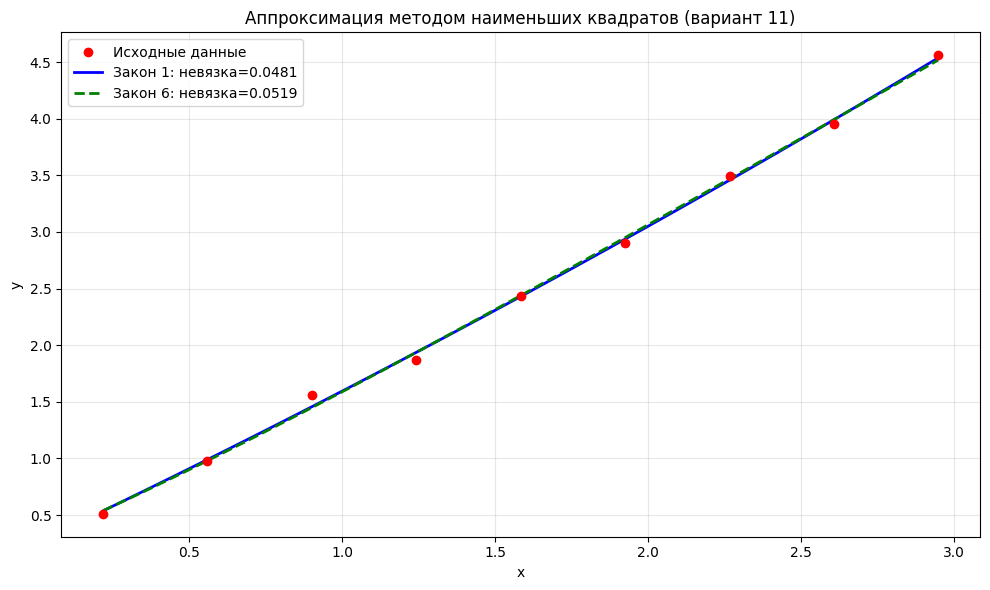

In [16]:
x_plot = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Исходные данные', zorder=5)

y_plot1 = model1(x_plot, a1, b1, c1)
plt.plot(x_plot, y_plot1, 'b-', label=f'Закон 1: невязка={delta1:.4f}', linewidth=2)

y_plot6 = a6 * x_plot + b6 * np.exp(-x_plot) + c6
plt.plot(x_plot, y_plot6, 'g--', label=f'Закон 6: невязка={delta6:.4f}', linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Аппроксимация методом наименьших квадратов (вариант 11)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()